# From Power Flow to Dynamic Simulation: HELIOS + RAMSES on the Nordic Test System

This tutorial walks through the **complete static-to-dynamic workflow** of the
[STEPSS](https://stepss.sps-lab.org) platform, using only the
[stepss](https://stepss.sps-lab.org/python/) Python package:

1. **[HELIOS](https://stepss.sps-lab.org/python/helios/)**, the AC power-flow engine,
   loads the Nordic system, **increases every Central-area load by 10 %**, and solves
   the new operating point;
2. the solution is **exported to the two places that need it**: a re-loadable static
   data file (the power-flow model) and a `volt_rat` file (the initial conditions for
   dynamic simulation);
3. **RAMSES**, the dynamic simulator, initializes the system directly on that
   solution and simulates the **trip of generator g2**;
4. the frequency and voltage evolution of the stressed system is **compared against
   the original operating point B** subjected to the same disturbance.

No file is edited by hand at any point: HELIOS writes exactly what RAMSES reads.
That hand-over is the point of this tutorial.

**Installation** (already done on the course JupyterHub, and needed only if you run
this elsewhere):

```bash
pip install jupyter ipython stepss
```

On Linux the engine additionally needs the system libraries
`libopenblas0 libgfortran5 libgomp1`
(see the [installation guide](https://stepss.sps-lab.org/python/installation/)).

## The Nordic test system

The Nordic test system is the IEEE PES benchmark for voltage-stability studies
(IEEE PES Technical Report **PES-TR19**, *Test Systems for Voltage Stability Analysis
and Security Assessment*; full data in `doc/Nordic_test_system_V6.pdf` of this
repository). It has 74 buses at five voltage levels (400 / 220 / 130 / 20 / 15 kV),
20 synchronous machines with AVRs, governors and PSSs, and is split into four areas:

![Nordic test system one-line diagram](nordic_oneline.png)

- **North**: hydro generation, surplus power;
- **Central**: the load centre, heavily importing from the North;
- **South**: additional load, loosely connected;
- **Equiv**: an external equivalent behind bus 4072, whose large machine **g20 is
  the slack bus** of the power flow.

Every load is connected to a 20-kV distribution bus fed through a transformer with a
**load tap changer (LTC)** that regulates the distribution-side voltage. The North → Central
power transfer and the LTC behaviour are what make this system the classic vehicle
for studying long-term voltage dynamics.

We start from **operating point B**, the *secure* operating point of the benchmark.

## The data files, and who reads what

| File | Contents | Read by |
|------|----------|---------|
| `lf_B.dat` | Static network model **and** power-flow data of operating point B (buses, lines, transformers with LTC data, generators, slack) | **HELIOS** |
| `dyn_B.dat` | Dynamic models: machines, AVRs, governors, PSSs, voltage-dependent loads, LTC controllers (`DCTL LTC2`), shunts | **RAMSES** |
| `volt_rat_B.dat` | The *solved operating point*: transformer ratios and every bus voltage (`LFRESV` records) | **RAMSES** (initialization) |
| `settings1.dat` | Time-integration and solver settings | RAMSES |
| `obs.dat` | Which variables to record (here: wildcards, so everything) | RAMSES |
| `trip_gen.dst` | The disturbance scenario | RAMSES |

The split matters. Look at a `LOAD` record inside `dyn_B.dat`:

```
LOAD L_11 11 1. 1. 0. 0.   0. 1. 1.0 0. 0. 0. 0. 1. 2.0 0. 0. 0. ;
```

The consumed powers (fields 5–6) are **`0. 0.`**, deliberately. RAMSES computes each
injector's initial power *from the power-flow solution* supplied in the `volt_rat`
file. So when we change the loads and re-solve, **`dyn_B.dat` does not change at all**:
the entire new operating point travels in one regenerated `volt_rat` file. That is
the bridge we are about to build with HELIOS.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import stepss
from stepss.helios import HeliosSession

print('stepss', stepss.__version__)

stepss 3.77


In [2]:
# Plot style used throughout: recessive grid, no chart junk, fixed series colors.
plt.rcParams.update({
    'figure.figsize': (9, 4.2),
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.6,
    'lines.linewidth': 1.8,
    'font.size': 11,
    'legend.frameon': False,
})

COL_B = '#2a78d6'       # blue:    operating point B (base case)
COL_PLUS10 = '#eb6834'  # orange:  operating point B + 10% Central load
COL_3 = '#1baf7a'       # aqua
COL_4 = '#eda100'       # yellow

## Part 1: The power flow, with HELIOS

`stepss.helios.HeliosSession` wraps the HELIOS engine that ships inside the
stepss package; there is nothing extra to install. A session follows a
**load → modify → solve → query** lifecycle.

In [3]:
pf = HeliosSession()          # it is also a context manager: `with HeliosSession() as pf:`
print(pf.build_info())

pf.load_file('../lf_B.dat')
converged = pf.solve()
print(f'converged: {converged} in {pf.iterations} iteration(s), '
      f'largest mismatch {max(pf.max_mismatch):.3f} MVA')

helios 1.4.1 (GNU, Linux)
converged: True in 1 iteration(s), largest mismatch 0.067 MVA


One iteration: `lf_B.dat` already *stores* the solved operating point B, so
Newton–Raphson only has to confirm it. Let us look at what we loaded.

In [4]:
names = pf.bus_names()
v_pu, _ = pf.get_bus_voltages()
p_load, q_load = pf.get_bus_loads()
p_gen, q_gen, _ = pf.get_generator_outputs()

print(f'{pf.bus_count} buses, {pf.branch_count} branches, {pf.generator_count} generators')
print(f'total load       : {p_load.sum():8.1f} MW  {q_load.sum():8.1f} Mvar')
print(f'total generation : {p_gen.sum():8.1f} MW  ->  network losses {p_gen.sum() - p_load.sum():.1f} MW')
print(f'voltage range    : {v_pu.min():.4f} pu ({names[v_pu.argmin()]})  to  '
      f'{v_pu.max():.4f} pu ({names[v_pu.argmax()]})')

77 buses, 105 branches, 23 generators
total load       :  11060.0 MW    3054.8 Mvar
total generation :  11343.4 MW  ->  network losses 283.4 MW
voltage range    : 0.9930 pu (2)  to  1.1206 pu (4032)


### The operating point, on the one-line diagram

`nordic.svg`, in the repository root, is a diagram *template*: the `%A`-`%U` codes in its
text elements are placeholders that HELIOS replaces with solved values. `write_diagram`
substitutes whatever solution the session currently holds, so the same two lines re-run
after the load increase below render the stressed operating point instead.

Voltage magnitudes are in red and phase angles in gold at all 74 buses; machine and load
injections are in blue and green; the 400 kV corridors carry the active and reactive flow at
each end, positive out of the bus into the branch.

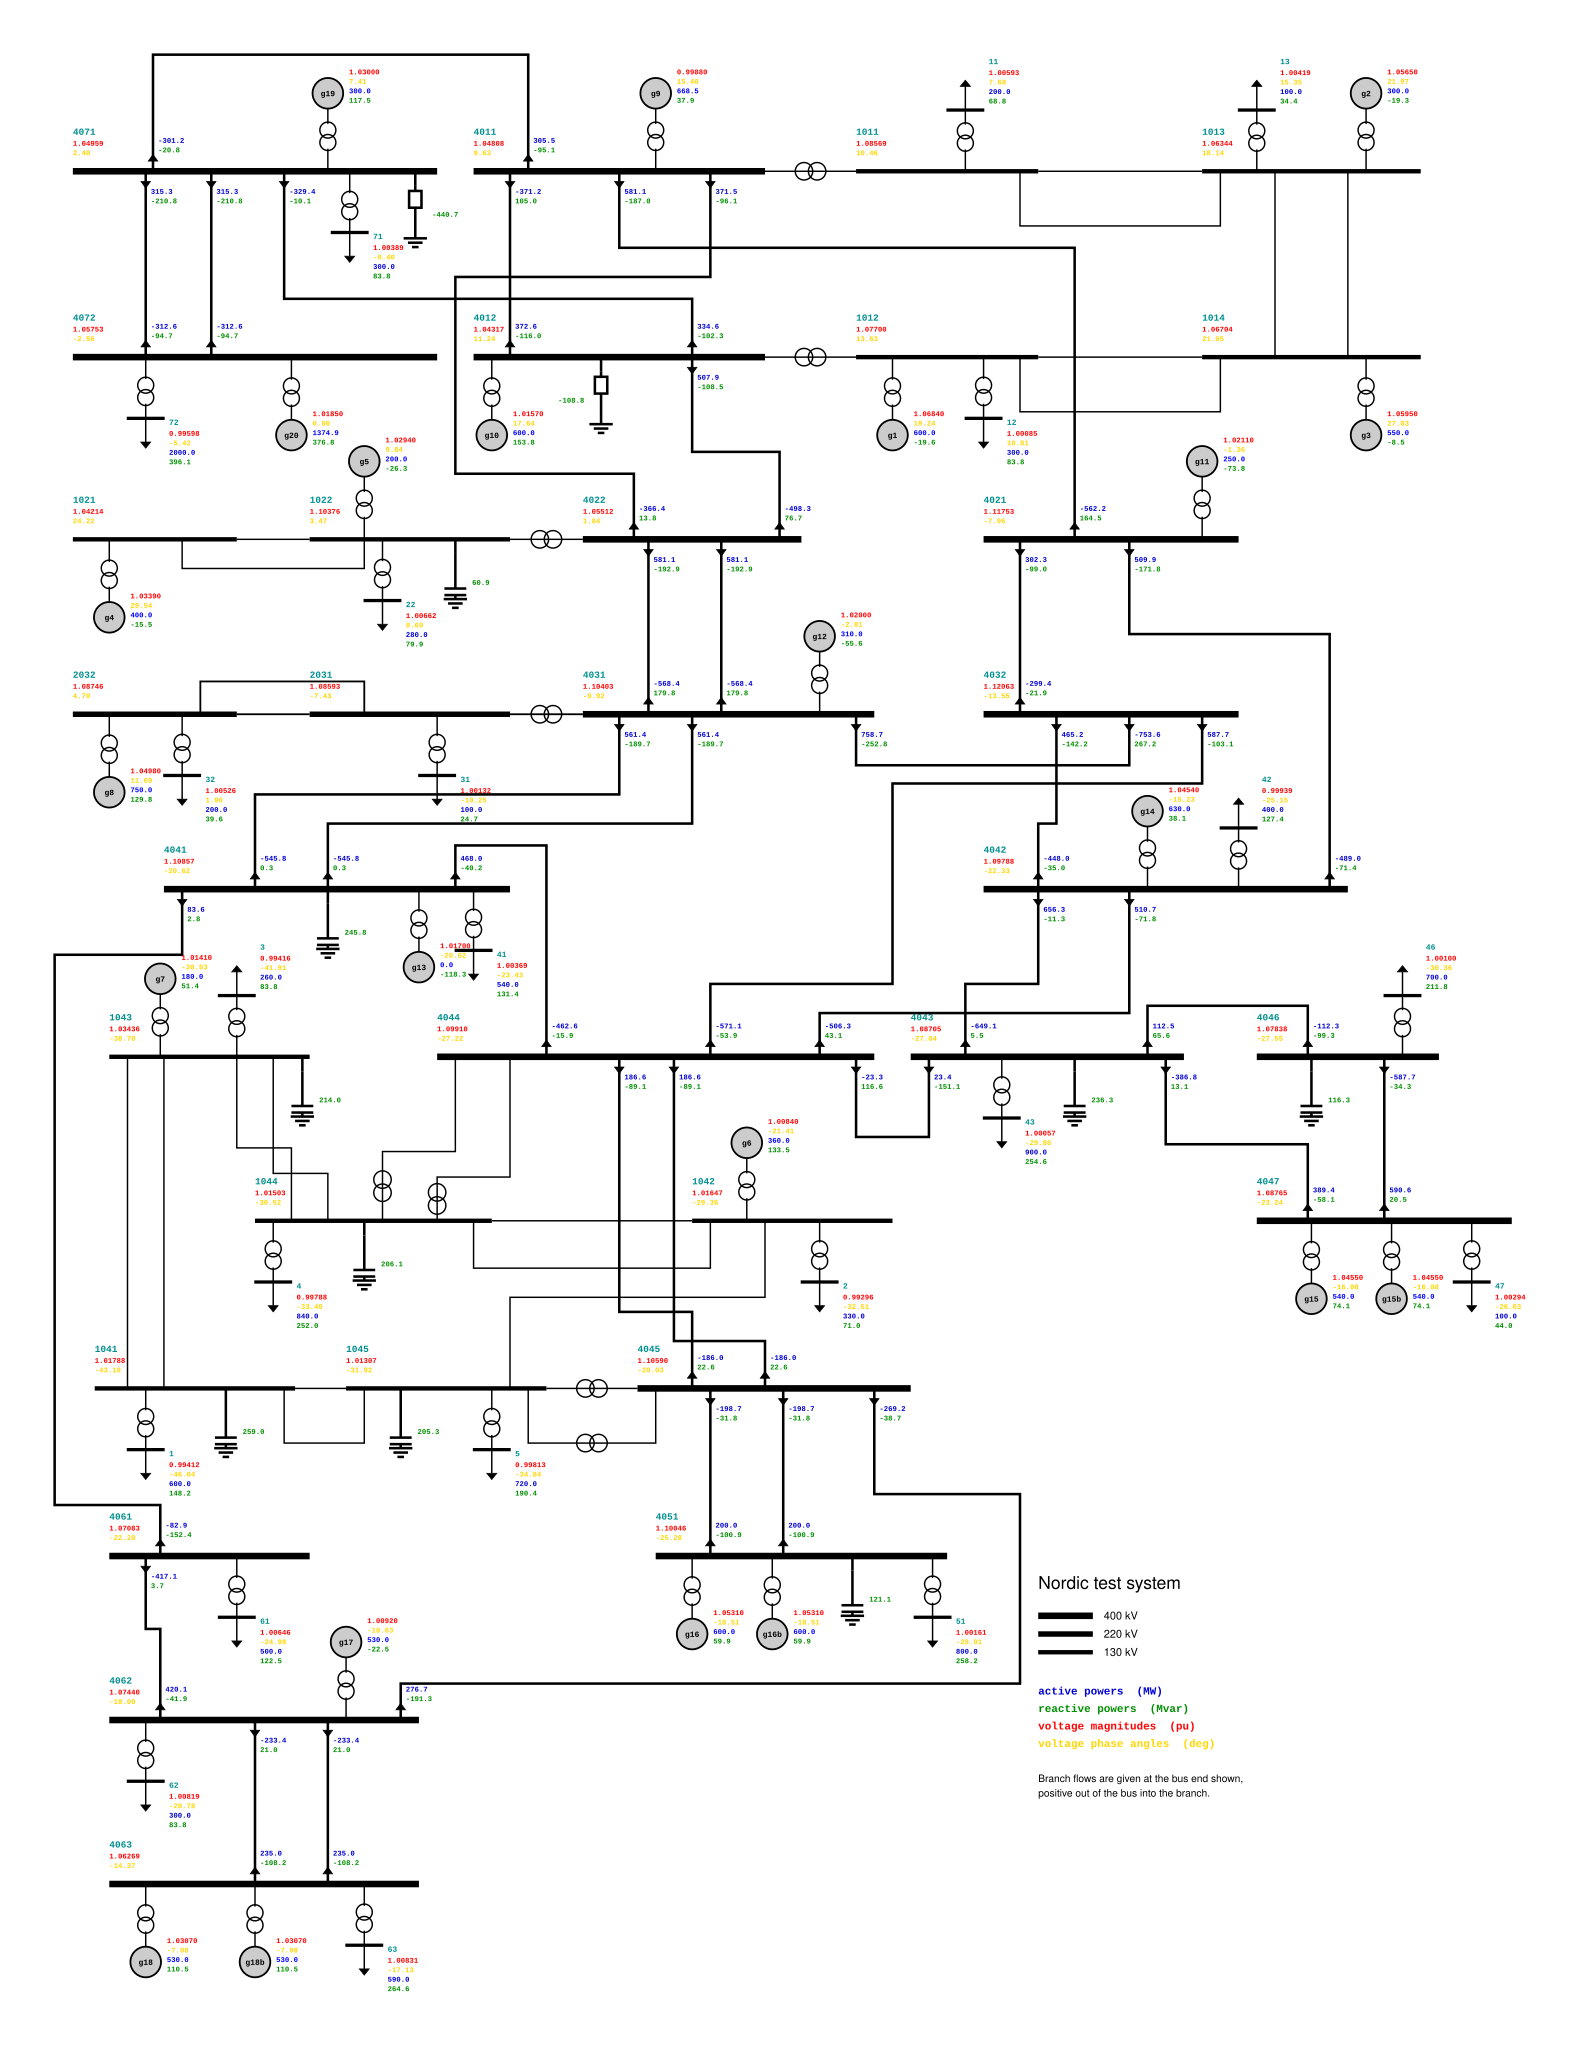

In [5]:
from IPython.display import SVG, display

pf.write_diagram('../nordic.svg', 'nordic_B_solved.svg')
display(SVG('nordic_B_solved.svg'))

### Stressing the Central area

The Central area hosts eleven loads, all on 20-kV distribution buses (see the
one-line diagram: buses 1–5 hang under the 130-kV ring, buses 41–51 under the
400-kV grid).

In [6]:
CENTRAL_LOADS = ['1', '2', '3', '4', '5', '41', '42', '43', '46', '47', '51']

base = {b: pf.get_bus_info(b) for b in CENTRAL_LOADS}
print(f'{"bus":>4} {"P [MW]":>8} {"Q [Mvar]":>9}')
for b, info in base.items():
    print(f'{b:>4} {info.p_load_mw:8.1f} {info.q_load_mvar:9.1f}')
p_central = sum(i.p_load_mw for i in base.values())
print(f'\nCentral-area load: {p_central:.1f} MW '
      f'(of {p_load.sum():.1f} MW system total)')

 bus   P [MW]  Q [Mvar]
   1    600.0     148.2
   2    330.0      71.0
   3    260.0      83.8
   4    840.0     252.0
   5    720.0     190.4
  41    540.0     131.4
  42    400.0     127.4
  43    900.0     254.6
  46    700.0     211.8
  47    100.0      44.0
  51    800.0     258.2

Central-area load: 6190.0 MW (of 11060.0 MW system total)


We now raise every one of these loads by **10 %** at **constant power factor**
(P and Q scaled by the same factor), an extra **619 MW** that the North must ship
south across the transfer corridor.

Two modelling points, both worth being pedantic about:

- **Who supplies the extra power?** The `GENER` records of this file carry no
  participation factors, so `apply_changes()` leaves every generator setpoint
  untouched and the **slack bus (g20, the external equivalent) absorbs the whole
  increase**, plus the extra network losses. This mirrors how the published
  `lf_B_plus_*` variants of this repository were built.
- **Why in steps?** A 619-MW jump is too far from the last solution for
  Newton–Raphson to converge in one go (try it!). We walk there in five 2 % steps,
  re-solving after each: the standard *continuation* approach used to trace PV
  curves. `set_load()` takes absolute targets, so the steps do not compound
  rounding errors.

After every `apply_changes()` HELIOS re-runs the full solver: LTC transformers move
their taps to re-regulate their controlled buses and generators are switched to
their reactive-power limits where needed.

In [7]:
steps = [{'factor': 1.0, 'p_central': p_central,
          'v1041': pf.get_bus_voltage('1041')[0],
          'v4044': pf.get_bus_voltage('4044')[0],
          'g20': pf.get_generator_info('g20').p_mw}]

print(f'{"factor":>7} {"central [MW]":>13} {"V(1041) [pu]":>13} {"V(4044) [pu]":>13} {"g20 [MW]":>10} {"iters":>6}')
r = steps[0]
print(f"{r['factor']:7.2f} {r['p_central']:13.1f} {r['v1041']:13.4f} {r['v4044']:13.4f} {r['g20']:10.1f} {'-':>6}")

for k in range(1, 6):
    factor = 1.0 + 0.02 * k
    for b in CENTRAL_LOADS:
        pf.set_load(b, base[b].p_load_mw * factor, base[b].q_load_mvar * factor)
    converged = pf.apply_changes()
    assert converged, f'power flow did not converge at factor {factor}'
    r = {'factor': factor,
         'p_central': sum(pf.get_bus_info(b).p_load_mw for b in CENTRAL_LOADS),
         'v1041': pf.get_bus_voltage('1041')[0],
         'v4044': pf.get_bus_voltage('4044')[0],
         'g20': pf.get_generator_info('g20').p_mw}
    steps.append(r)
    print(f"{r['factor']:7.2f} {r['p_central']:13.1f} {r['v1041']:13.4f} {r['v4044']:13.4f} {r['g20']:10.1f} {pf.iterations:6d}")

 factor  central [MW]  V(1041) [pu]  V(4044) [pu]   g20 [MW]  iters
   1.00        6190.0        1.0179        1.0991     1374.9      -
   1.02        6313.8        1.0078        1.0872     1519.5      4
   1.04        6437.6        1.0062        1.0739     1669.3      7
   1.06        6561.4        0.9974        1.0588     1826.2      6
   1.08        6685.2        0.9978        1.0417     1991.2      6
   1.10        6809.0        0.9934        1.0199     2169.5      8


In [8]:
# The five re-solves just traced the upper part of a PV curve.
fig, ax = plt.subplots()
x = [r['p_central'] for r in steps]
for key, label, colr in [('v1041', 'bus 1041 (130 kV)', COL_B),
                         ('v4044', 'bus 4044 (400 kV)', COL_PLUS10)]:
    y = [r[key] for r in steps]
    ax.plot(x, y, marker='o', markersize=5, color=colr, label=label)
    ax.annotate(label, (x[-1], y[-1]), xytext=(8, 0), textcoords='offset points',
                va='center', color='0.25', fontsize=10)
ax.set_xlabel('Central-area load (MW)')
ax.set_ylabel('voltage (pu)')
ax.set_title('Transmission voltages sag as the Central load grows', loc='left')
ax.set_xlim(x[0] - 30, x[-1] + 320)
ax.legend(loc='lower left')
plt.show()

Note what the LTCs hide: the 20-kV *distribution* voltages barely move (each LTC
keeps its controlled bus inside its deadband by tapping), so the entire stress is
pushed onto the *transmission* voltages plotted above: the classic mechanism of
long-term voltage instability.

### Exporting the new operating point

The solved `+10 %` operating point lands in one file:

- **`write_dump()`** → `lf_B_plus10pct.dat`, a complete, re-loadable data file in
  the same format as `lf_B.dat`, refreshed with the new loads, generator outputs,
  tap positions and voltages. It is both the new power-flow case and the file the
  dynamic run below reads its network and initial state from.
- **`write_voltrat()`** → `volt_rat_B_plus10pct.dat`, the same solution in the form
  the HELIOS `VT` command writes: one `LFRESV` record per bus and one record per
  regulating transformer. Nothing below needs it; it is written here because the
  tap positions are easiest to read in it.


In [9]:
pf.write_dump('lf_B_plus10pct.dat')           # the new case, network and solution
pf.write_voltrat('volt_rat_B_plus10pct.dat')  # the same solution, VT format
pf.close()

with open('volt_rat_B_plus10pct.dat') as f:
    lines = f.readlines()
print(''.join(lines[:3]) + '...\n' + ''.join(lines[77:79]))


LFRESV g1       1.0684000  3.32236679e-02 ;
LFRESV g2       1.0565000  7.72366951e-02 ;
LFRESV g3       1.0595000  1.67384755e-01 ;
...
TRANSFO 1044-4044            1044     4044                0           10            0            0          101            0         1000 1 ;
TRANSFO 1044-4044-2          1044     4044                0           10            0            0          101            0         1000 1 ;



Compare the exported ratios with `../volt_rat_B.dat`: 22 of the 26 LTC ratios have
moved (e.g. transformer 1045–4045 from 109 % down to 102 %): the taps the solver
turned to keep the distribution voltages regulated at the higher load.


## Part 2: The dynamic simulation, with RAMSES

The disturbance scenario is the distributed `trip_gen.dst`:

In [10]:
print(open('../trip_gen_long.dst').read())

  0.000 CONTINUE SOLVER BD 0.010 0.001 0.0 ALL
  1.000 BREAKER SYNC_MACH g2 0
  5.000 CONTINUE SOLVER BD 0.010 0.001 0.0 ALL
120.000 STOP



Line by line: at $t=0$ the solver is configured (second-order BD integration,
10-ms step); at $t=1\,$s the breaker of **synchronous machine g2** (a 300-MW hydro
unit in the North) opens; at $t=120\,$s the simulation stops.

A RAMSES case is assembled from the same files HELIOS just read, with a single
substitution: the load-flow file is now **the one HELIOS just wrote**. The dynamic
file is untouched, because it describes no network and no operating point.


In [11]:
# clear outputs of any previous run
for f in glob.glob('*.trace') + glob.glob('*.trj'):
    os.remove(f)

In [12]:
case = stepss.cfg()
case.addData('lf_B_plus10pct.dat')          # network and operating point, written above
case.addData('../dyn_B.dat')                # dynamic models, untouched
case.addData('../settings1.dat')            # solver settings
case.addObs('../obs.dat')                   # record all observables
case.addDst('../trip_gen_long.dst')         # disturbance: trip g2 at t = 1 s
case.addTrj('output_plus10.trj')            # binary trajectory file (for the extractor)
case.addOut('output_plus10.trace')          # simulation log
case.addInit('init_plus10.trace')           # initialization report

ram_plus10 = stepss.sim()
ram_plus10.execSim(case, 0.0)               # read data, initialize, pause at t = 0
print(f'initialized and paused at t = {ram_plus10.getSimTime():.3f} s')

initialized and paused at t = 0.001 s


Before continuing, verify the hand-over actually happened: the initialization
report lists every injector's starting point, *derived from the power-flow
solution*; no load power was typed into any dynamic file.

In [13]:
for line in open(case.getInit()):
    fields = line.split()
    if len(fields) == 6 and fields[0] == 'LOAD' and fields[2] in CENTRAL_LOADS:
        print(f'{fields[1]:>6}  bus {fields[2]:>3}  V = {fields[3]} pu  '
              f'P = {-float(fields[4]):8.1f} MW  Q = {-float(fields[5]):7.1f} Mvar')

  L_01  bus   1  V = 0.9986 pu  P =    660.0 MW  Q =   163.0 Mvar
  L_02  bus   2  V = 1.0050 pu  P =    363.0 MW  Q =    78.1 Mvar
  L_03  bus   3  V = 1.0025 pu  P =    286.0 MW  Q =    92.2 Mvar
  L_04  bus   4  V = 1.0053 pu  P =    924.0 MW  Q =   277.2 Mvar
  L_05  bus   5  V = 1.0061 pu  P =    792.0 MW  Q =   209.4 Mvar
  L_41  bus  41  V = 0.9913 pu  P =    594.0 MW  Q =   144.5 Mvar
  L_42  bus  42  V = 0.9965 pu  P =    440.0 MW  Q =   140.1 Mvar
  L_43  bus  43  V = 0.9998 pu  P =    990.0 MW  Q =   280.1 Mvar
  L_46  bus  46  V = 0.9975 pu  P =    770.0 MW  Q =   233.0 Mvar
  L_47  bus  47  V = 1.0000 pu  P =    110.0 MW  Q =    48.4 Mvar
  L_51  bus  51  V = 0.9912 pu  P =    880.0 MW  Q =   284.0 Mvar


Exactly the +10 % values (e.g. load 41: $540 \times 1.1 = 594$ MW). Now release the
simulation; it runs until the `STOP` event of the disturbance file.

In [14]:
ram_plus10.contSim(ram_plus10.getInfTime())   # run to the end of the scenario (t = 120 s)

0

### Extracting results

`stepss.extractor` parses the binary trajectory file. Every recorded quantity
comes back as a `(time, value)` series with a one-line `.plot()` convenience.
Here is the quickest possible look at the tripped machine's bus voltage:

In [15]:
ext_plus10 = stepss.extractor(case.getTrj())
ext_plus10.getBus('g2').mag.plot()

### The same disturbance from the original operating point

To see what the extra 619 MW cost the system, we repeat the identical experiment
from the **distributed operating point B**: same dynamic data, same disturbance,
only the `volt_rat` file differs (the original `volt_rat_B.dat`).

In [16]:
case_b = stepss.cfg()
for f in ['../lf_B.dat', '../dyn_B.dat', '../settings1.dat']:
    case_b.addData(f)
case_b.addObs('../obs.dat')
case_b.addDst('../trip_gen_long.dst')
case_b.addTrj('output_B.trj')
case_b.addOut('output_B.trace')
case_b.addInit('init_B.trace')

ram_b = stepss.sim()
ram_b.execSim(case_b)                       # no pause: initialize and run to the end
ext_b = stepss.extractor(case_b.getTrj())

## Part 3: Frequency and voltage evolution

**Frequency** first. We plot the speed of the centre-of-inertia (COI) reference,
the "system frequency", for both cases.

In [17]:
fig, ax = plt.subplots()
for ext, label, colr in [(ext_b, 'operating point B', COL_B),
                         (ext_plus10, 'B + 10% Central load', COL_PLUS10)]:
    f = ext.getSync('g6').SC        # COI speed deviation (pu), identical for every machine
    ax.plot(f.time, 50.0 * (1.0 + f.value), color=colr, label=label)
ax.axhline(50.0, color='0.55', linewidth=0.8, linestyle='--')
ax.axvline(1.0, color='0.55', linewidth=0.8, linestyle=':')
ax.annotate('g2 trips', (1.0, ax.get_ylim()[0]), xytext=(6, 6),
            textcoords='offset points', color='0.35', fontsize=10)
ax.set_xlabel('time (s)')
ax.set_ylabel('COI frequency (Hz)')
ax.set_title('System frequency after the loss of g2 (300 MW)', loc='left')
ax.legend(loc='upper right')
plt.show()

Losing g2 removes 300 MW of generation: the frequency dips, the governors of the
remaining machines open their gates, and the system settles **below 50 Hz** on the
combined droop of the primary frequency control; there is no secondary control
(AGC) in this model to bring it back. The two curves nearly coincide: frequency is
a *system-wide active-power* phenomenon, and both cases lose the same 300 MW with
the same spinning reserve.

**Voltage** tells a different story: it is *local*, and the Central area is where
the stress lives. Bus 1041 sits at the 130-kV heart of the load centre:

In [18]:
fig, ax = plt.subplots()
for ext, label, colr in [(ext_b, 'operating point B', COL_B),
                         (ext_plus10, 'B + 10% Central load', COL_PLUS10)]:
    v = ext.getBus('1041').mag
    ax.plot(v.time, v.value, color=colr, label=label)
    ax.annotate(label, (v.time[-1], v.value[-1]), xytext=(8, 0),
                textcoords='offset points', va='center', color='0.25', fontsize=10)
ax.axvline(1.0, color='0.55', linewidth=0.8, linestyle=':')
ax.set_xlabel('time (s)')
ax.set_ylabel('voltage at bus 1041 (pu)')
ax.set_title('Central-area transmission voltage: same event, more stressed system', loc='left')
ax.set_xlim(right=145)
ax.legend(loc='lower right')
plt.show()

The stressed system starts ~2.5 % lower and dips deeper. Two time scales are
visible: the fast ripples in the first ~20 s are the **electromechanical
oscillations** of the machines against each other, while the slow recovery over
the following minute is the **long-term dynamics**: AVRs holding the generator
voltages while the LTCs tap (first move ~30 s after the voltage leaves the
deadband, further moves every 8–12 s, see the `DCTL LTC2` records in `dyn_B.dat`)
to restore the distribution-side voltages, and with them the load powers.

The spatial picture across the four areas, for the stressed case:

In [19]:
fig, ax = plt.subplots()
for bus, label, colr in [('1011', 'bus 1011, North (130 kV)', COL_B),
                         ('1041', 'bus 1041, Central (130 kV)', COL_PLUS10),
                         ('4044', 'bus 4044, Central (400 kV)', COL_3),
                         ('4062', 'bus 4062, South (400 kV)', COL_4)]:
    v = ext_plus10.getBus(bus).mag
    ax.plot(v.time, v.value, color=colr, label=label)
    ax.annotate(label.split(',')[0], (v.time[-1], v.value[-1]), xytext=(8, 0),
                textcoords='offset points', va='center', color='0.25', fontsize=10)
ax.axvline(1.0, color='0.55', linewidth=0.8, linestyle=':')
ax.set_xlabel('time (s)')
ax.set_ylabel('voltage (pu)')
ax.set_title('Voltage evolution across the areas (B + 10% Central load)', loc='left')
ax.set_xlim(right=140)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncols=2)
plt.show()

And who replaced g2's 300 MW? Primary frequency control shares the burden in
proportion to machine size: each remaining unit picks up only a handful of MW,
individually invisible and collectively decisive. So we plot the lost unit, the
largest single responder (the big equivalent g20), and the **sum over all other
machines**, as *changes* from pre-trip output:

In [20]:
GENS = [f'g{i}' for i in range(1, 21)] + ['g15b', 'g16b', 'g18b']

def dp(gen):
    p = ext_plus10.getSync(gen).P
    return p.time, p.value - p.value[0]

t, dp_g2 = dp('g2')
_, dp_g20 = dp('g20')
dp_rest = -dp_g2 * 0.0
for g in GENS:
    if g not in ('g2', 'g20'):
        dp_rest = dp_rest + dp(g)[1]

fig, ax = plt.subplots()
for series, label, colr in [(dp_g2, 'g2 (tripped)', COL_B),
                            (dp_g20, 'g20 (largest unit)', COL_PLUS10),
                            (dp_rest, 'all 21 other machines', COL_3)]:
    ax.plot(t, series, color=colr, label=label)
    ax.annotate(f'{series[-1]:+.0f} MW', (t[-1], series[-1]), xytext=(8, 0),
                textcoords='offset points', va='center', color='0.25', fontsize=10)
ax.axhline(0.0, color='0.55', linewidth=0.8, linestyle='--')
ax.axvline(1.0, color='0.55', linewidth=0.8, linestyle=':')
ax.set_xlabel('time (s)')
ax.set_ylabel('change in active power (MW)')
ax.set_title('Who replaces the lost 300 MW?', loc='left')
ax.set_xlim(right=138)
ax.legend(loc='center right')
plt.show()

In [21]:
# Key outcomes, side by side.
print(f'{"":32}{"point B":>12} {"B + 10%":>12}')
for label, fn in [
        ('initial V(1041) [pu]', lambda e: e.getBus('1041').mag.value[0]),
        ('lowest V(1041) [pu]',  lambda e: e.getBus('1041').mag.value.min()),
        ('final V(1041) [pu]',   lambda e: e.getBus('1041').mag.value[-1]),
        ('frequency nadir [Hz]', lambda e: 50 * (1 + e.getSync('g6').SC.value.min())),
        ('settling frequency [Hz]', lambda e: 50 * (1 + e.getSync('g6').SC.value[-1]))]:
    print(f'{label:32}{fn(ext_b):12.4f} {fn(ext_plus10):12.4f}')

                                     point B      B + 10%
initial V(1041) [pu]                  1.0179       0.9934
lowest V(1041) [pu]                   0.9965       0.9707
final V(1041) [pu]                    1.0180       0.9935
frequency nadir [Hz]                 49.7743      49.7824
settling frequency [Hz]              49.9245      49.9216


## What you have seen

- **HELIOS** solved, modified (`set_load` + `apply_changes`), re-solved, and exported
  a power system, entirely from Python, with no input file edited by hand.
- The **`volt_rat` file is the bridge**: `write_voltrat()` output is directly a RAMSES
  input, because the dynamic data (`dyn_B.dat`) deliberately contains no operating-point
  information.
- **RAMSES** initialized on the new operating point and simulated the loss of g2:
  a system-wide *frequency* response settled by governor droop, and a *local voltage*
  response shaped by AVR limits and LTC dynamics, visibly degraded at the higher
  loading.

### Things to try

- Push the Central load further (12 %, 15 %, …): at what loading does the power flow
  stop converging? And does the *dynamic* response after the g2 trip remain stable all
  the way there? (It should give in earlier: statically feasible is not dynamically
  secure.)
- Trip a Central machine (edit a copy of `trip_gen.dst`, e.g. `g6` or `g14`) instead of
  the Northern g2 and watch the voltage plots.
- Explore other observables: `ext_plus10.getSync('g6').FC` (field current, watch the
  overexcitation), `.getTor('g6').Pm`, `ext_plus10.getBus('1').mag` (an LTC-regulated
  20-kV bus).

### References

- stepss documentation: <https://stepss.sps-lab.org/python/> (API reference,
  [HELIOS guide](https://stepss.sps-lab.org/python/helios/))
- STEPSS user guide: <https://stepss.sps-lab.org/user-guide/>
- IEEE PES-TR19, *Test Systems for Voltage Stability Analysis and Security Assessment*,
  2015: the Nordic test system report (`doc/Nordic_test_system_V6.pdf`)